# Spatial component — results figures and tables (Chapter 6)

Builds the figures and the numbers of the Results section of the spatial component
(ZINB + BYM2, model **M1**):

- **Figure 1 (2x2 maps)** — (a) recorded landslides per slope unit; (b) expected landslide
  density $\lambda_i$ (landslides per km²); (c) susceptibility classes; (d) analysis domain
  of the rainfall thresholds.
- **Figure 2** — rate ratios of the fixed effects with their 95 % credible intervals.
- **Tables for the text** — classes, success-rate curve, analysis domain and its overlap
  with the physical criterion, Pearson residuals and neighbourhood graph.

Same design rules as `static_variables_cap6.ipynb`, so both figures look alike in the thesis:
no panel titles, letters (a)–(d) in the upper-left corner, legend inside each panel
(lower right), frame on the four sides, lat/lon only on the left and bottom axes, slope units
without outline, and the AMVA boundary as the only line.

**Inputs** (all written by `SUSCEPTIBILIDAD_v2.qmd`; paths relative to its folder):

| File | Chunk that writes it | Used for |
|---|---|---|
| `salidas/su_resultados_ZINB_BYM2.gpkg` | `exportar` | maps and tables |
| `salidas/tabla_rate_ratios.csv` | `rr` | Figure 2 |
| `slope_units_final_mm.gpkg` | — | mean slope, only for the domain check (section 8) |
| `amva.geojson` | — | boundary line |

**Colores.** (a) usa azules y (b)–(c) la rampa amarilla-roja: son dos magnitudes distintas
(conteo observado contra densidad esperada) y no deben leerse en la misma escala. Los colores
de (c) son exactamente los de la curva de éxito (`curva_exito_con_clases.R`), para que el mapa
y la curva se lean juntos. Ninguna usa los colores de los niveles de alerta de la matriz.

> Si reajustas M1 sin los registros posteriores al 31-mar-2025 (`M1_train`), vuelve a
> exportar `su_resultados_ZINB_BYM2.gpkg` y a correr este notebook: todas las cifras salen
> de aquí.

## 1. Libraries and settings

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator, FixedLocator, NullLocator
from shapely.geometry import Polygon, MultiPolygon

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,        # fuentes TrueType incrustadas en el PDF
})

# ---------------------------------------------------------------- settings
PATH_RES   = 'salidas/su_resultados_ZINB_BYM2.gpkg'
PATH_RR    = 'salidas/tabla_rate_ratios.csv'
PATH_SU    = 'slope_units_final_mm.gpkg'
PATH_AMVA  = '/home/oisanchezp/Thesis/data/metadata/amva.geojson'
OUT_DIR    = Path('00Figuras/06Seccion')
OUT_MAPS   = 'fig_zinb_maps_cap6'
OUT_RR     = 'fig_rate_ratios_cap6'

CRS_PLOT   = 'EPSG:4326'   # geographic CRS, so ticks are in degrees
SIMPLIFY_M = 5             # simplification for DRAWING only (metres); 0 = off
EDGECOLOR  = 'none'        # no outline on the slope units themselves
DRAW_AMVA  = True
AMVA_LW    = 0.8
AMVA_COLOR = 'black'

INK   = '#1a1a19'          # texto
MUTED = '#6b6b6b'          # texto secundario y elementos no significativos

OUT_DIR.mkdir(parents=True, exist_ok=True)
print('geopandas', gpd.__version__)

geopandas 1.1.4


## 2. Load the model results

`mm` is the recorded count, `mu_count` the expected count of the negative binomial component
and `lambda` = `mu_count` / `area_km2`, the expected density. The cell stops if a column is
missing, if there are NaN, or if `lambda` is not `mu_count / area_km2`.

In [2]:
res = gpd.read_file(PATH_RES)
print(f'Slope units : {len(res):,} | CRS: {res.crs}')

REQUIRED = ['su_id', 'area_km2', 'mm', 'mu_count', 'lambda', 'clase_susc',
            'r_pearson', 'incluir_parte2', 'cobertura']
missing = [c for c in REQUIRED if c not in res.columns]
if missing:
    raise KeyError(f'Faltan columnas en {PATH_RES}: {missing}')
if res[REQUIRED].isna().any().any():
    raise ValueError('Hay NaN en las columnas del modelo:\n'
                     + res[REQUIRED].isna().sum().to_string())
if res.crs is None or res.crs.is_geographic:
    raise ValueError('Se espera un CRS proyectado (metros).')

dif = float(np.abs(res['lambda'] - res['mu_count'] / res['area_km2']).max())
assert dif < 1e-6, f'lambda no es mu_count/area_km2 (diferencia max {dif:.3g})'
res['incluir_parte2'] = res['incluir_parte2'].astype(bool)

N      = len(res)
N_LS   = int(res['mm'].sum())
N_SULS = int((res['mm'] > 0).sum())
AREA   = float(res['area_km2'].sum())
DENS_VALLEY = N_LS / AREA

print(f'Landslides          : {N_LS:,} in {N_SULS:,} slope units ({100*N_SULS/N:.1f} %)')
print(f'Modelled area       : {AREA:,.1f} km2')
print(f'Valley mean density : {DENS_VALLEY:.2f} landslides/km2')
print(f'Sum of mu_count     : {res["mu_count"].sum():,.0f} (recorded: {N_LS:,})')
print('\nlambda percentiles (landslides/km2):')
print(res['lambda'].quantile([.05, .25, .50, .75, .95, .99]).round(2).to_string())
# La suma de mu_count supera a la observada: es la media posterior de exp(eta),
# que por la asimetria de la posterior es mayor que exp(media de eta). No
# afecta el orden de las unidades (clases, curva de exito); solo la escala
# absoluta de lambda en el mapa (b).

Slope units : 60,914 | CRS: EPSG:32618
Landslides          : 6,198 in 4,060 slope units (6.7 %)
Modelled area       : 992.9 km2
Valley mean density : 6.24 landslides/km2
Sum of mu_count     : 7,552 (recorded: 6,198)

lambda percentiles (landslides/km2):
0.05     0.16
0.25     0.96
0.50     3.02
0.75     8.17
0.95    32.41
0.99    74.81


## 3. Classes for the maps

- **(a)** counts: 0 | 1 | 2–3 | ≥ 4. Casi tres de cada cuatro unidades con deslizamientos
  tienen uno solo; un corte más alto (≥ 10) dejaría una clase de una decena de unidades,
  invisible en el mapa.
- **(b)** density on a logarithmic scale (< 1, 1–3, 3–10, 10–30, 30–100, ≥ 100 per km²):
  cada clase es unas tres veces la anterior, así se lee igual en todo el rango.
- **(c)** the four classes of the Methods (50 / 80 / 95 % of the inventory).
- **(d)** retained / excluded, with the flag `incluir_parte2` written by the qmd.

Las leyendas van de mayor a menor, igual en los cuatro paneles.

In [14]:
# --- (a) recorded landslides per slope unit -------------------------------
COUNT_BINS = [-0.5, 0.5, 1.5, 3.5, np.inf]
COUNT_CATS = ['0', '1', '2–3', '≥ 4']
COUNT_COLS = ['#e3e3e3', '#6baed6', '#3182bd', '#08519c']     # gris + Blues

# --- (b) expected density, landslides per km2 -----------------------------
LAM_BINS = [0, 1, 3, 10, 30, 100, np.inf]
LAM_CATS = ['< 1', '1–3', '3–10', '10–30', '30–100', '≥ 100']
LAM_COLS = ['#fed976', '#feb24c', '#fd8d3c', '#fc4e2a', '#e31a1c', '#b10026']

# --- (c) susceptibility classes (mismos colores que la curva de exito) ----
SUSC_FROM_ES = {'Muy alta': 'Very high', 'Alta': 'High',
                'Media': 'Moderate', 'Baja': 'Low'}
SUSC_CATS = ['Low', 'Moderate', 'High', 'Very high']
SUSC_COLS = ["#0044ff", '#12ff55', '#ffbe00', '#ff0000']   # Low, Moderate, High, Very high

# --- (d) analysis domain --------------------------------------------------
DOM_CATS = ['Retained', 'Excluded']
DOM_COLS = ['#e3e3e3', '#4a3aa7']

res['cls_count']  = pd.cut(res['mm'], COUNT_BINS, labels=COUNT_CATS).astype(str)
res['cls_lambda'] = pd.cut(res['lambda'], LAM_BINS, labels=LAM_CATS,
                           right=False).astype(str)
res['cls_susc']   = res['clase_susc'].map(SUSC_FROM_ES)
res['cls_domain'] = np.where(res['incluir_parte2'], 'Retained', 'Excluded')

bad = res.loc[res['cls_susc'].isna(), 'clase_susc'].unique()
if len(bad):
    raise ValueError(f'Clases de susceptibilidad sin traducir: {bad}')

for col, cats in [('cls_count', COUNT_CATS), ('cls_lambda', LAM_CATS),
                  ('cls_susc', SUSC_CATS), ('cls_domain', DOM_CATS)]:
    c = res[col].value_counts().reindex(cats, fill_value=0)
    print(f'--- {col}')
    print(pd.DataFrame({'units': c, '%': (100 * c / N).round(1)}).to_string(), '\n')

--- cls_count
           units     %
cls_count             
0          56854  93.3
1           2926   4.8
2–3          915   1.5
≥ 4          219   0.4 

--- cls_lambda
            units     %
cls_lambda             
< 1         15662  25.7
1–3         14704  24.1
3–10        17819  29.3
10–30        9289  15.2
30–100       3144   5.2
≥ 100         296   0.5 

--- cls_susc
           units     %
cls_susc              
Low        38240  62.8
Moderate   14234  23.4
High        6119  10.0
Very high   2321   3.8 

--- cls_domain
            units     %
cls_domain             
Retained    55228  90.7
Excluded     5686   9.3 



## 4. Geometry preparation

Geometries are simplified for drawing only and reprojected to `EPSG:4326`. If `amva.geojson`
is not found, the outer outline of the slope units is drawn instead (útil para revisar la
figura; la versión final debe usar `amva.geojson`, como todas las figuras del capítulo).

In [15]:
def outer_outline(gdf):
    # Contorno exterior de un conjunto de poligonos, sin los huecos interiores.
    merged = gdf.geometry.buffer(1).union_all().buffer(-1)
    parts = merged.geoms if isinstance(merged, MultiPolygon) else [merged]
    shell = MultiPolygon([Polygon(p.exterior) for p in parts if p.area > 1e6])
    return gpd.GeoSeries([shell], crs=gdf.crs)


amva = None
if DRAW_AMVA:
    if Path(PATH_AMVA).exists():
        amva = gpd.read_file(PATH_AMVA).to_crs(res.crs).dissolve().geometry
        print('AMVA boundary read from', PATH_AMVA)
    else:
        print(f'AVISO - no encuentro {PATH_AMVA}: dibujo el contorno de las slope units')
        amva = outer_outline(res)
    amva = amva.to_crs(CRS_PLOT)

su_plot = res.copy()
if SIMPLIFY_M:
    su_plot['geometry'] = su_plot.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
su_plot = su_plot.to_crs(CRS_PLOT)

b = su_plot.total_bounds
if amva is not None:
    a = amva.total_bounds
    b = [min(b[0], a[0]), min(b[1], a[1]), max(b[2], a[2]), max(b[3], a[3])]
XMIN, YMIN, XMAX, YMAX = b
PADX = (XMAX - XMIN) * 0.01
PADY = (YMAX - YMIN) * 0.03
print(f'Bounds: lon {XMIN:.3f} to {XMAX:.3f} | lat {YMIN:.3f} to {YMAX:.3f}')

AMVA boundary read from /home/oisanchezp/Thesis/data/metadata/amva.geojson
Bounds: lon -75.719 to -75.221 | lat 5.978 to 6.512


## 5. Panel helper

The same helper as in `static_variables_cap6.ipynb`, unchanged.

In [16]:
def fmt_lon(x, _):
    return f'{abs(x):.2f}° {"W" if x < 0 else "E"}'


def fmt_lat(y, _):
    return f'{abs(y):.2f}° {"S" if y < 0 else "N"}'


def add_panel(ax, gdf, column, categories, colors, label, legend_title,
              legend_loc='lower right', ncol=1, ylabel_rotation=90):
    # Draw one categorical slope-unit map: no title, letter in the upper-left
    # corner, legend in the lower right, frame on four sides, ticks left/bottom.
    for cat, col in zip(categories, colors):
        sub = gdf[gdf[column] == cat]
        if len(sub):
            # rasterized: los poligonos van como imagen a 300 dpi dentro del PDF
            # (texto, ejes y limite siguen vectoriales); el PDF pasa de ~25 MB a pocos MB
            sub.plot(ax=ax, color=col, edgecolor=EDGECOLOR, linewidth=0.0, zorder=2,
                     rasterized=True)

    if amva is not None:
        amva.boundary.plot(ax=ax, color=AMVA_COLOR, linewidth=AMVA_LW, zorder=5)

    pairs = [(c, k) for c, k in zip(categories, colors) if (gdf[column] == c).any()]
    handles = [Patch(facecolor=k, edgecolor='0.35', linewidth=0.4, label=c)
               for c, k in pairs]
    leg = ax.legend(handles=handles, title=legend_title, loc=legend_loc,
                    frameon=True, framealpha=0.95, edgecolor='0.45',
                    ncol=ncol, borderpad=0.6, handlelength=1.3,
                    handleheight=1.0, labelspacing=0.35)
    leg.get_frame().set_linewidth(0.6)
    leg.set_zorder(10)
    leg._legend_box.align = 'left'

    ax.set_xlim(XMIN - PADX, XMAX + PADX)
    ax.set_ylim(YMIN - PADY, YMAX + PADY)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.8); sp.set_color('black')

    ax.tick_params(which='both', direction='out', length=3, width=0.7,
                   top=False, right=False, labeltop=False, labelright=False,
                   bottom=True, left=True, labelbottom=True, labelleft=True,
                   labelsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune='both'))
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
    ax.tick_params(axis='y', rotation=ylabel_rotation)
    for t in ax.get_yticklabels():
        t.set_va('center')
    ax.set_xlabel(''); ax.set_ylabel('')

    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, fontweight='bold', zorder=10,
            bbox=dict(boxstyle='square,pad=0.30', facecolor='white',
                      edgecolor='0.45', linewidth=0.6))
    return ax

## 6. Figure 1 — composite map

Drawing 61,000 polygons four times takes a couple of minutes.

Saved: 00Figuras/06Seccion/fig_zinb_maps_cap6.png


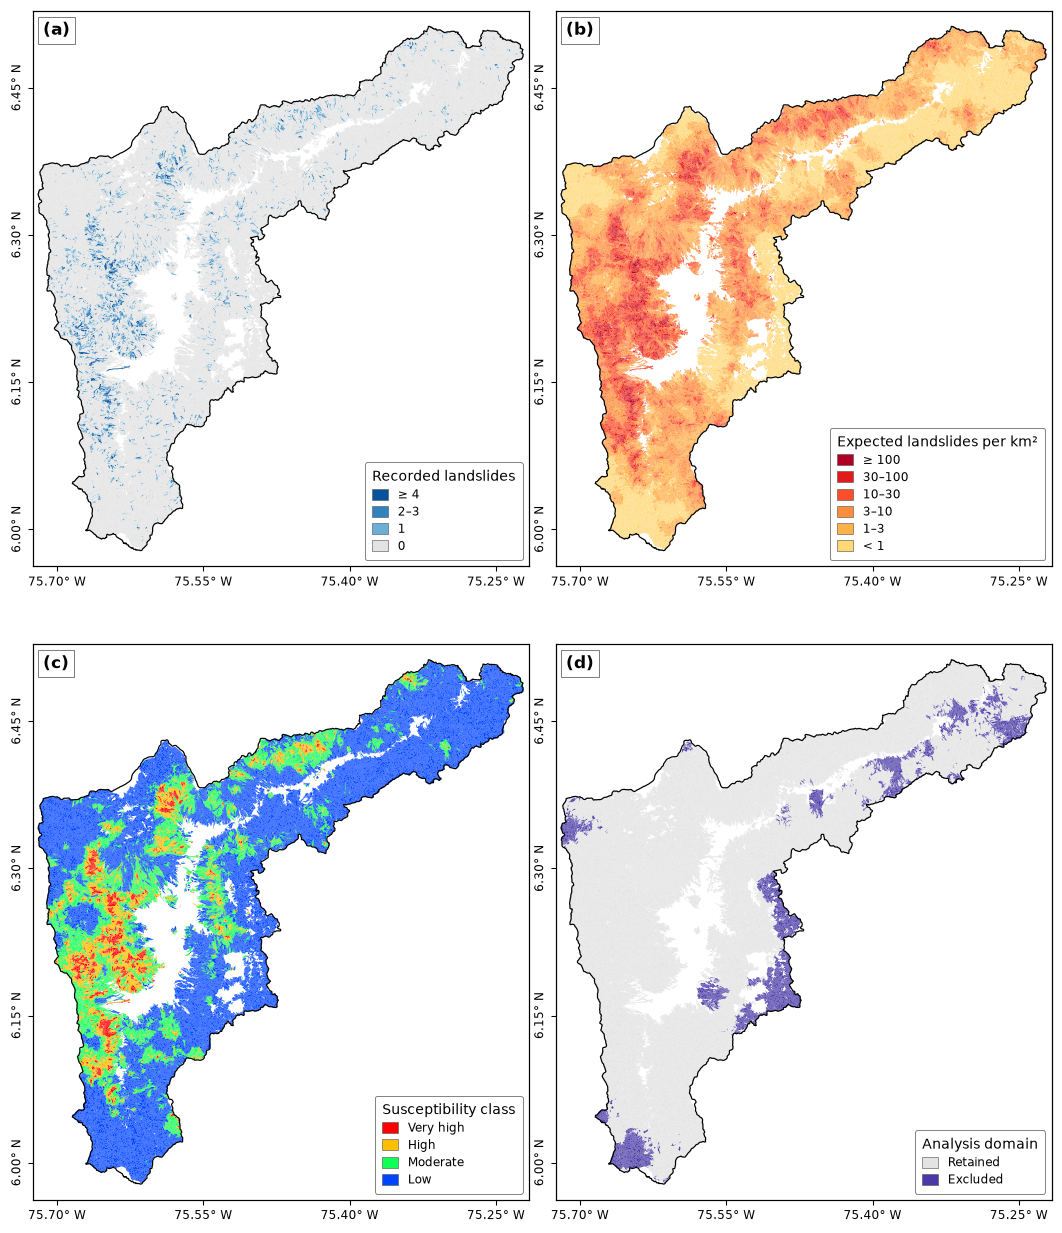

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 11.5), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.01, hspace=0.01)

add_panel(axes[0, 0], su_plot, 'cls_count',  COUNT_CATS[::-1], COUNT_COLS[::-1],
          '(a)', 'Recorded landslides')
add_panel(axes[0, 1], su_plot, 'cls_lambda', LAM_CATS[::-1],   LAM_COLS[::-1],
          '(b)', 'Expected landslides per km²')
add_panel(axes[1, 0], su_plot, 'cls_susc',   SUSC_CATS[::-1],  SUSC_COLS[::-1],
          '(c)', 'Susceptibility class')
add_panel(axes[1, 1], su_plot, 'cls_domain', DOM_CATS,         DOM_COLS,
          '(d)', 'Analysis domain')

fig.savefig(OUT_DIR / f'{OUT_MAPS}.png')
fig.savefig(OUT_DIR / f'{OUT_MAPS}.pdf')
print('Saved:', OUT_DIR / f'{OUT_MAPS}.png')
plt.show()

## 7. Figure 2 — rate ratios of the fixed effects

Reads the table written by the chunk `rr` of the qmd (`exp` of the posterior mean and of the
2.5 and 97.5 % quantiles). The x axis is logarithmic, so an effect that halves the density and
one that doubles it sit at the same distance from 1. Filled black points: the 95 % credible
interval excludes 1; grey: it does not. Each group shows its reference level as a hollow point
on the line of no effect. The numbers on the right are the same values, so the figure doubles
as the table.

Saved: 00Figuras/06Seccion/fig_rate_ratios_cap6.png


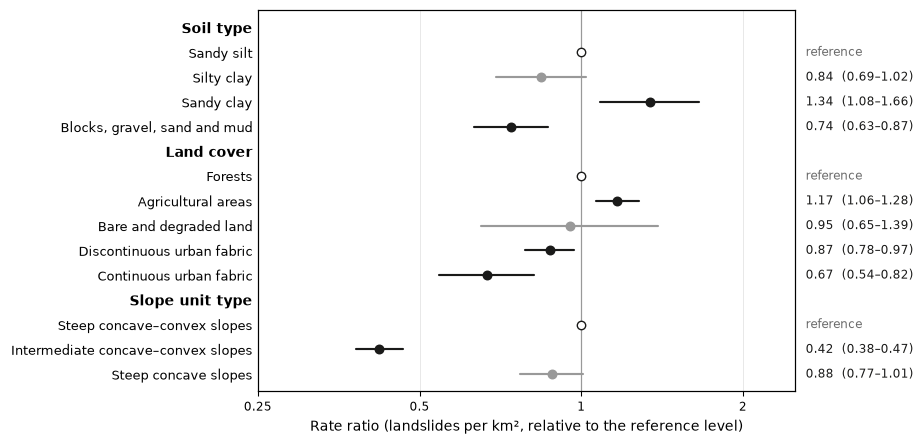

In [23]:
TERMS = {   # termino de INLA -> (grupo, etiqueta en ingles)
    'sueloLimo-arcilloso':                  ('Soil type', 'Silty clay'),
    'sueloAreno-arcilloso':                 ('Soil type', 'Sandy clay'),
    'sueloBloques, gravas, arenas y lodos': ('Soil type', 'Blocks, gravel, sand and mud'),
    'cobertura2': ('Land cover', 'Agricultural areas'),
    'cobertura4': ('Land cover', 'Bare and degraded land'),
    'cobertura1': ('Land cover', 'Discontinuous urban fabric'),
    'cobertura0': ('Land cover', 'Continuous urban fabric'),
    'tipo_su2':   ('Slope unit type', 'Intermediate concave–convex slopes'),
    'tipo_su3':   ('Slope unit type', 'Steep concave slopes'),
}
REFERENCE = {'Soil type': 'Sandy silt', 'Land cover': 'Forests',
             'Slope unit type': 'Steep concave–convex slopes'}
GROUPS = ['Soil type', 'Land cover', 'Slope unit type']

rr = pd.read_csv(PATH_RR)
rr = rr[rr['termino'] != '(Intercept)'].copy()
unknown = sorted(set(rr['termino']) - set(TERMS))
if unknown:
    raise KeyError(f'Terminos sin etiqueta en TERMS: {unknown}')
rr['group'] = rr['termino'].map(lambda t: TERMS[t][0])
rr['level'] = rr['termino'].map(lambda t: TERMS[t][1])
rr['sig']   = (rr['RR_lo'] > 1) | (rr['RR_hi'] < 1)

# filas en el orden de la figura: cabecera de grupo, referencia, niveles
rows = []
for g in GROUPS:
    rows.append(('header', g, None))
    rows.append(('ref', REFERENCE[g], None))
    order = [lab for (gg, lab) in TERMS.values() if gg == g]
    for lab in order:
        r = rr[(rr['group'] == g) & (rr['level'] == lab)]
        if len(r):
            rows.append(('level', lab, r.iloc[0]))

fig, ax = plt.subplots(figsize=(6.3, 0.26 * len(rows) + 0.6))
y = np.arange(len(rows))[::-1]
XLIM = (0.25, 2.5)

ax.axvline(1, color='0.60', linewidth=0.8, zorder=1)
for yi, (kind, lab, r) in zip(y, rows):
    if kind == 'header':
        continue
    if kind == 'ref':
        ax.plot(1, yi, 'o', ms=5.5, mfc='white', mec=INK, mew=0.9, zorder=3)
        txt = 'reference'
    else:
        c = INK if r['sig'] else '0.60'
        ax.plot([r['RR_lo'], r['RR_hi']], [yi, yi], color=c, linewidth=1.4,
                solid_capstyle='round', zorder=2)
        ax.plot(r['RR'], yi, 'o', ms=5.5, color=c, zorder=3)
        txt = f"{r['RR']:.2f}  ({r['RR_lo']:.2f}–{r['RR_hi']:.2f})"
    ax.text(1.02, yi, txt, transform=ax.get_yaxis_transform(), ha='left',
            va='center', fontsize=8, color=MUTED if kind == 'ref' else INK)

# etiquetas: los grupos en negrita, en la misma columna que los niveles
ax.set_yticks(y)
ax.set_yticklabels([lab for (_, lab, _) in rows], fontsize=8.5)
for t, (kind, _, _) in zip(ax.get_yticklabels(), rows):
    t.set_fontweight('bold' if kind == 'header' else 'normal')
    t.set_fontsize(9 if kind == 'header' else 8.5)

ax.set_xscale('log')
ax.set_xlim(*XLIM)
ax.xaxis.set_major_locator(FixedLocator([0.25, 0.5, 1, 2]))
ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.set_xlabel('Rate ratio (landslides per km², relative to the reference level)')
# for side in ('top', 'right'):
#     ax.spines[side].set_visible(False)
# for side in ('left', 'bottom'):
#     ax.spines[side].set_linewidth(0.7); ax.spines[side].set_color('0.35')
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3, width=0.7, labelsize=8)
ax.grid(axis='x', color='0.90', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
# ax.text(1.02, 1.0, 'Rate ratio (95 % CrI)', transform=ax.transAxes, ha='left',
#         va='bottom', fontsize=8, color=MUTED)

fig.savefig(OUT_DIR / f'{OUT_RR}.png')
fig.savefig(OUT_DIR / f'{OUT_RR}.pdf')
print('Saved:', OUT_DIR / f'{OUT_RR}.png')
plt.show()

## 8. Tables for the text

### 8.1 Susceptibility classes and success-rate curve

`Ratio to valley mean` is the density of the class divided by the density of the whole
valley; it is the number behind the rule of the decision matrix (only the classes more than
an order of magnitude away from the mean shift the alert level). The AUC uses the same
trapezoid formula as the qmd.

In [8]:
g = res.groupby('cls_susc')
tab = pd.DataFrame({
    'Slope units': g.size(),
    'Area (km2)': g['area_km2'].sum(),
    'Landslides': g['mm'].sum(),
    'Units with landslides': g['mm'].apply(lambda s: int((s > 0).sum())),
    'lambda min': g['lambda'].min(),
    'lambda max': g['lambda'].max(),
}).reindex(SUSC_CATS[::-1])
tab['% units'] = 100 * tab['Slope units'] / N
tab['% area'] = 100 * tab['Area (km2)'] / AREA
tab['% landslides'] = 100 * tab['Landslides'] / N_LS
tab['% units with landslides'] = 100 * tab['Units with landslides'] / tab['Slope units']
tab['Density (landslides/km2)'] = tab['Landslides'] / tab['Area (km2)']
tab['Ratio to valley mean'] = tab['Density (landslides/km2)'] / DENS_VALLEY
print(tab.round(2).T.to_string())
tab.round(4).to_csv(OUT_DIR / 'tabla_res_clases.csv')

# --- success-rate curve ---------------------------------------------------
o = np.argsort(-res['lambda'].to_numpy(), kind='mergesort')
cum_ls   = np.cumsum(res['mm'].to_numpy()[o]) / N_LS
cum_area = np.cumsum(res['area_km2'].to_numpy()[o]) / AREA
auc = float(np.sum(np.diff(np.r_[0, cum_area]) * (np.r_[0, cum_ls[:-1]] + cum_ls) / 2))
pts = {f'{int(100*a)} % of the area': 100 * cum_ls[np.searchsorted(cum_area, a)]
       for a in (0.01, 0.05, 0.10, 0.20)}
print(f'\nSuccess-rate AUC: {auc:.3f}')
for k, v in pts.items():
    print(f'  {k:>18}: {v:.1f} % of the landslides')
pd.Series({'AUC': auc, **pts}).to_csv(OUT_DIR / 'tabla_res_curva_exito.csv')

cls_susc                  Very high     High  Moderate       Low
Slope units                 2321.00  6119.00  14234.00  38240.00
Area (km2)                    35.56    96.13    224.88    636.29
Landslides                  3098.00  1858.00    932.00    310.00
Units with landslides       1482.00  1427.00    847.00    304.00
lambda min                    38.05    14.94      4.82      0.00
lambda max                   519.56    38.04     14.94      4.82
% units                        3.81    10.05     23.37     62.78
% area                         3.58     9.68     22.65     64.09
% landslides                  49.98    29.98     15.04      5.00
% units with landslides       63.85    23.32      5.95      0.79
Density (landslides/km2)      87.12    19.33      4.14      0.49
Ratio to valley mean          13.96     3.10      0.66      0.08

Success-rate AUC: 0.913
     1 % of the area: 25.3 % of the landslides
     5 % of the area: 57.6 % of the landslides
    10 % of the area: 74.0 % of the 

### 8.2 Analysis domain: sensitivity to *q* and overlap with the physical criterion

Same rule as the qmd: a unit is retained if it has a recorded landslide or if its $\lambda$
exceeds the $q$ percentile of $\lambda$ among the units without landslides. The physical
criterion is the lowest decile of mean slope or continuous urban fabric (`cobertura == "0"`).
`slope_mean` is not in the results file, so it is taken from `slope_units_final_mm.gpkg`,
filtered with the same complete-case rule as the qmd; the cell checks that both files line up
row by row (counts and areas identical) before using it.

In [9]:
lam0 = res.loc[res['mm'] == 0, 'lambda']
rows_q = []
for q in (0.05, 0.10, 0.15, 0.20):
    thr = lam0.quantile(q)
    inc = (res['mm'] > 0) | (res['lambda'] > thr)
    rows_q.append({'q': q, 'lambda threshold': thr, 'excluded units': int((~inc).sum()),
                   '% units': 100 * (~inc).mean(),
                   '% area': 100 * res.loc[~inc, 'area_km2'].sum() / AREA,
                   'landslides excluded': int(res.loc[~inc, 'mm'].sum())})
dom = pd.DataFrame(rows_q)
print(dom.round(3).to_string(index=False))
n_q10 = int(dom.loc[dom['q'] == 0.10, 'excluded units'].iloc[0])
assert n_q10 == int((~res['incluir_parte2']).sum()), \
    'q = 10 % no reproduce el indicador incluir_parte2 del qmd'

# --- mean slope, aligned with the modelled units -----------------------------
VARS = ['suelos', 'cobertura_cat', 'su_type', 'zona_lluvia']
su0 = gpd.read_file(PATH_SU, columns=VARS + ['n_mm', 'area', 'slope_mean'],
                    ignore_geometry=True)
su0 = su0[su0[VARS].notna().all(axis=1)].reset_index(drop=True)
aligned = (len(su0) == N
           and np.array_equal(su0['n_mm'].to_numpy(), res['mm'].to_numpy())
           and np.allclose(su0['area'].to_numpy(), res['area_km2'].to_numpy()))
if not aligned:
    raise ValueError('Los dos archivos no estan alineados fila a fila: '
                     'une por geometria antes de seguir.')
res['slope_mean'] = su0['slope_mean'].to_numpy()

excl = ~res['incluir_parte2']
p10 = res['slope_mean'].quantile(0.10)
phys = (res['slope_mean'] < p10) | (res['cobertura'].astype(str) == '0')
overlap = {
    'slope P10 (deg)': p10,
    'excluded units': int(excl.sum()),
    'excluded that meet the physical criterion (%)': 100 * phys[excl].mean(),
    'physical criterion in the whole valley (%)': 100 * phys.mean(),
    'physical units that are excluded (%)': 100 * excl[phys].mean(),
    'mean slope excluded (deg)': res.loc[excl, 'slope_mean'].mean(),
    'mean slope retained (deg)': res.loc[~excl, 'slope_mean'].mean(),
}
print()
for k, v in overlap.items():
    print(f'{k:>48}: {v:,.1f}')
print('\n', pd.crosstab(excl.rename('excluded'), phys.rename('physical criterion')))
dom.round(4).to_csv(OUT_DIR / 'tabla_res_dominio_q.csv', index=False)
pd.Series(overlap).round(3).to_csv(OUT_DIR / 'tabla_res_dominio_solape.csv')

   q  lambda threshold  excluded units  % units  % area  landslides excluded
0.05             0.152            2843    4.667   4.946                    0
0.10             0.307            5686    9.334   9.884                    0
0.15             0.450            8528   14.000  14.595                    0
0.20             0.644           11371   18.667  19.306                    0

                                 slope P10 (deg): 13.8
                                  excluded units: 5,686.0
   excluded that meet the physical criterion (%): 24.3
      physical criterion in the whole valley (%): 13.6
            physical units that are excluded (%): 16.7
                       mean slope excluded (deg): 20.9
                       mean slope retained (deg): 25.4

 physical criterion  False  True 
excluded                        
False               48326   6902
True                 4304   1382


### 8.3 Pearson residuals and neighbourhood graph

The graph is rebuilt with queen contiguity (`libpysal`) only to report its properties; the
model used the graph of the qmd (`poly2nb`, also queen). Compara con lo que imprime el chunk
`grafo`: si no coincide, reporta el del qmd.

In [10]:
rp = res['r_pearson']
print(f'Pearson residuals: mean {rp.mean():.3f} | sd {rp.std():.3f} | '
      f'> 3: {int((rp > 3).sum())} units | max {rp.max():.1f}')

try:
    from libpysal.weights import Queen
    w = Queen.from_dataframe(res, use_index=False, silence_warnings=True)
    card = np.array([len(v) for v in w.neighbors.values()])
    sizes = pd.Series(w.component_labels).value_counts()
    graph = {'units': w.n, 'mean neighbours': card.mean(), 'max neighbours': card.max(),
             'units without neighbours': len(w.islands),
             'connected components': w.n_components,
             'largest component (units)': int(sizes.iloc[0])}
    for k, v in graph.items():
        print(f'{k:>26}: {v:,.2f}' if isinstance(v, float) else f'{k:>26}: {v:,}')
    pd.Series(graph).to_csv(OUT_DIR / 'tabla_res_grafo.csv')
except ImportError:
    print('libpysal no esta instalado: usa las cifras del chunk `grafo` del qmd.')

Pearson residuals: mean -0.113 | sd 0.563 | > 3: 335 units | max 32.5
libpysal no esta instalado: usa las cifras del chunk `grafo` del qmd.


## 9. LaTeX snippets

```latex
\begin{figure}[!ht]
  \centering
  \includegraphics[width=0.90\textwidth]{00Figuras/06Seccion/fig_zinb_maps_cap6.pdf}
  \caption{Spatial component. (a) Landslides recorded in each slope unit over the inventory
  period; (b) expected landslide density $\lambda_i$ estimated by M1 (posterior mean);
  (c) susceptibility classes, whose boundaries enclose 50, 80 and 95\,\% of the recorded
  landslides; and (d) analysis domain of the rainfall thresholds, where the excluded units are
  those without landslides whose expected density falls in the lowest 10\,\% of that group.
  White areas are slope units that were not modelled. The black line is the boundary of the
  Aburr\'a Valley Metropolitan Area.}
  \label{fig:st-zinb-maps}
\end{figure}

\begin{figure}[!ht]
  \centering
  \includegraphics[width=0.85\textwidth]{00Figuras/06Seccion/fig_rate_ratios_cap6.pdf}
  \caption{Rate ratios of the terrain descriptors in M1, with 95\,\% credible intervals, on a
  logarithmic axis. Each ratio compares the expected landslide density of a level with that of
  the reference level of its group (hollow points). Black: the interval excludes one; grey: it
  does not.}
  \label{fig:st-rr}
\end{figure}
```